# Feature Selection — Remove Noise

1. Drop features with importance ≈ 0
2. Drop one of highly correlated pairs (|corr| > 0.9)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import ExtraTreesClassifier

from backend.infra.database import get_data_store
from backend.core.config import settings

store = get_data_store()
df = store.load_features()
print(f"{len(df)} rows, {len(df.columns)} columns (incl. Target)")

/Users/e.autenrieth/Documents/GitHub/ml-stock-prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The added token already exists in the token cache, skipping


Accessing as erikautenrieth

Initialized MLflow to track repo "erikautenrieth/stock-prediction-hub"

Repository erikautenrieth/stock-prediction-hub initialized!

2026-03-19 05:50:18 [info     ] dagshub_initialized            experiment=sp500_prediction repo=erikautenrieth/stock-prediction-hub tracking_uri=https://dagshub.com/erikautenrieth/stock-prediction-hub.mlflow
2026-03-19 05:50:19 [info     ] dagshub_storage_initialized    bucket=stock-prediction-hub
2026-03-19 05:50:19 [info     ] data_store_remote_enabled     
6376 rows, 68 columns (incl. Target)


In [2]:
# Split
X = df.drop("Target", axis=1)
y = df["Target"]

# Quick train to get importances
model = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X, y)

imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(f"Total features: {len(imp)}")
imp.head(20)

Total features: 67


ADX             0.021581
vol_roll60      0.020533
ADOSC           0.019563
+DMI            0.019255
-DMI            0.017379
vol_roll20      0.017215
ATR_norm        0.017183
MACD_SIGNAL     0.017144
vol_roll10      0.016484
BB_width        0.016474
MACD            0.016130
SAR             0.015944
OBV             0.015646
MACD_HIST       0.015627
ROC             0.015572
%D              0.015492
^BSESN Close    0.015347
RSI             0.015326
vol_roll5       0.015305
low_band        0.015097
dtype: float64

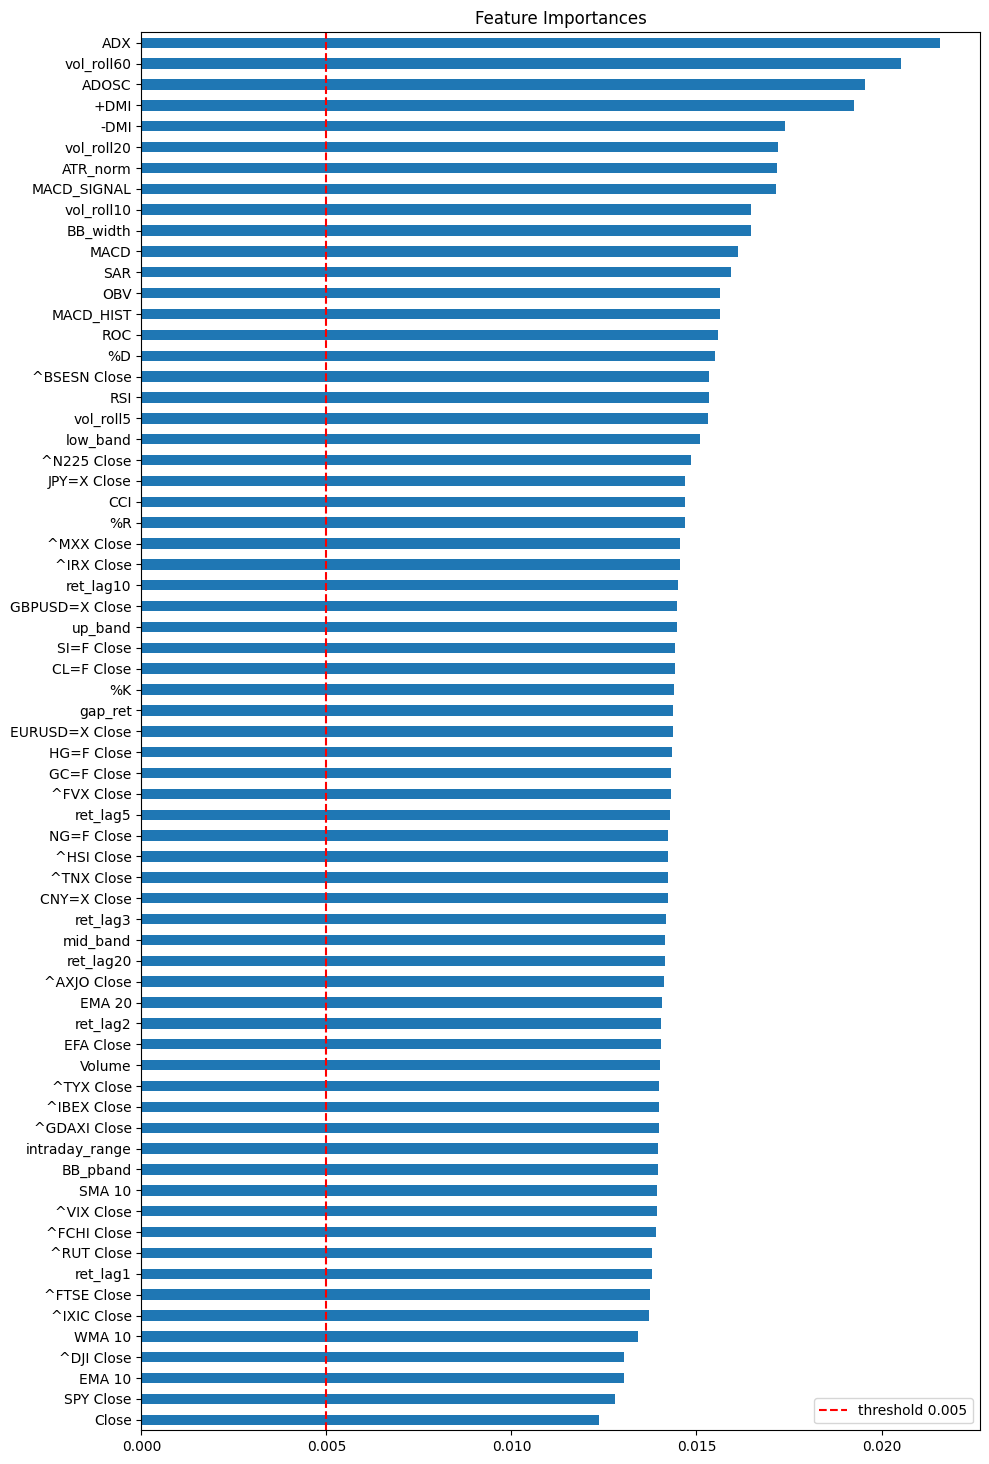

In [3]:
# Feature importances bar chart
fig, ax = plt.subplots(figsize=(10, max(6, len(imp) * 0.22)))
imp.sort_values().plot.barh(ax=ax)
ax.set_title("Feature Importances")
ax.axvline(x=0.005, color="red", linestyle="--", label="threshold 0.005")
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# Drop near-zero importance features
IMP_THRESHOLD = 0.005
low_imp = imp[imp < IMP_THRESHOLD].index.tolist()
print(f"Dropping {len(low_imp)} features with importance < {IMP_THRESHOLD}:")
print(low_imp)

Dropping 0 features with importance < 0.005:
[]


In [5]:
# Correlation matrix on remaining features
X_filtered = X.drop(columns=low_imp)
corr = X_filtered.corr().abs()

# Upper triangle only
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.9
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f"Dropping {len(to_drop_corr)} features with |corr| > {CORR_THRESHOLD}:")
print(to_drop_corr)

Dropping 17 features with |corr| > 0.9:
['EMA 10', 'EMA 20', 'WMA 10', 'MACD_SIGNAL', 'CCI', '%K', '%D', 'mid_band', 'BB_pband', 'vol_roll10', 'vol_roll20', '^IXIC Close', '^DJI Close', '^FCHI Close', '^FVX Close', '^TYX Close', 'SPY Close']


In [6]:
# Show correlated pairs
pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if val > CORR_THRESHOLD:
            pairs.append((idx, col, round(val, 3)))
pd.DataFrame(pairs, columns=["Feature A", "Feature B", "Correlation"])

,Feature A,Feature B,Correlation
0,SMA 10,EMA 10,0.981
1,EMA 10,EMA 20,0.944
2,SMA 10,WMA 10,0.975
3,EMA 10,WMA 10,0.968
4,MACD,MACD_SIGNAL,0.955
5,%R,CCI,0.937
6,%R,%K,1.000
7,CCI,%K,0.937
8,%R,%D,0.908
9,%K,%D,0.908


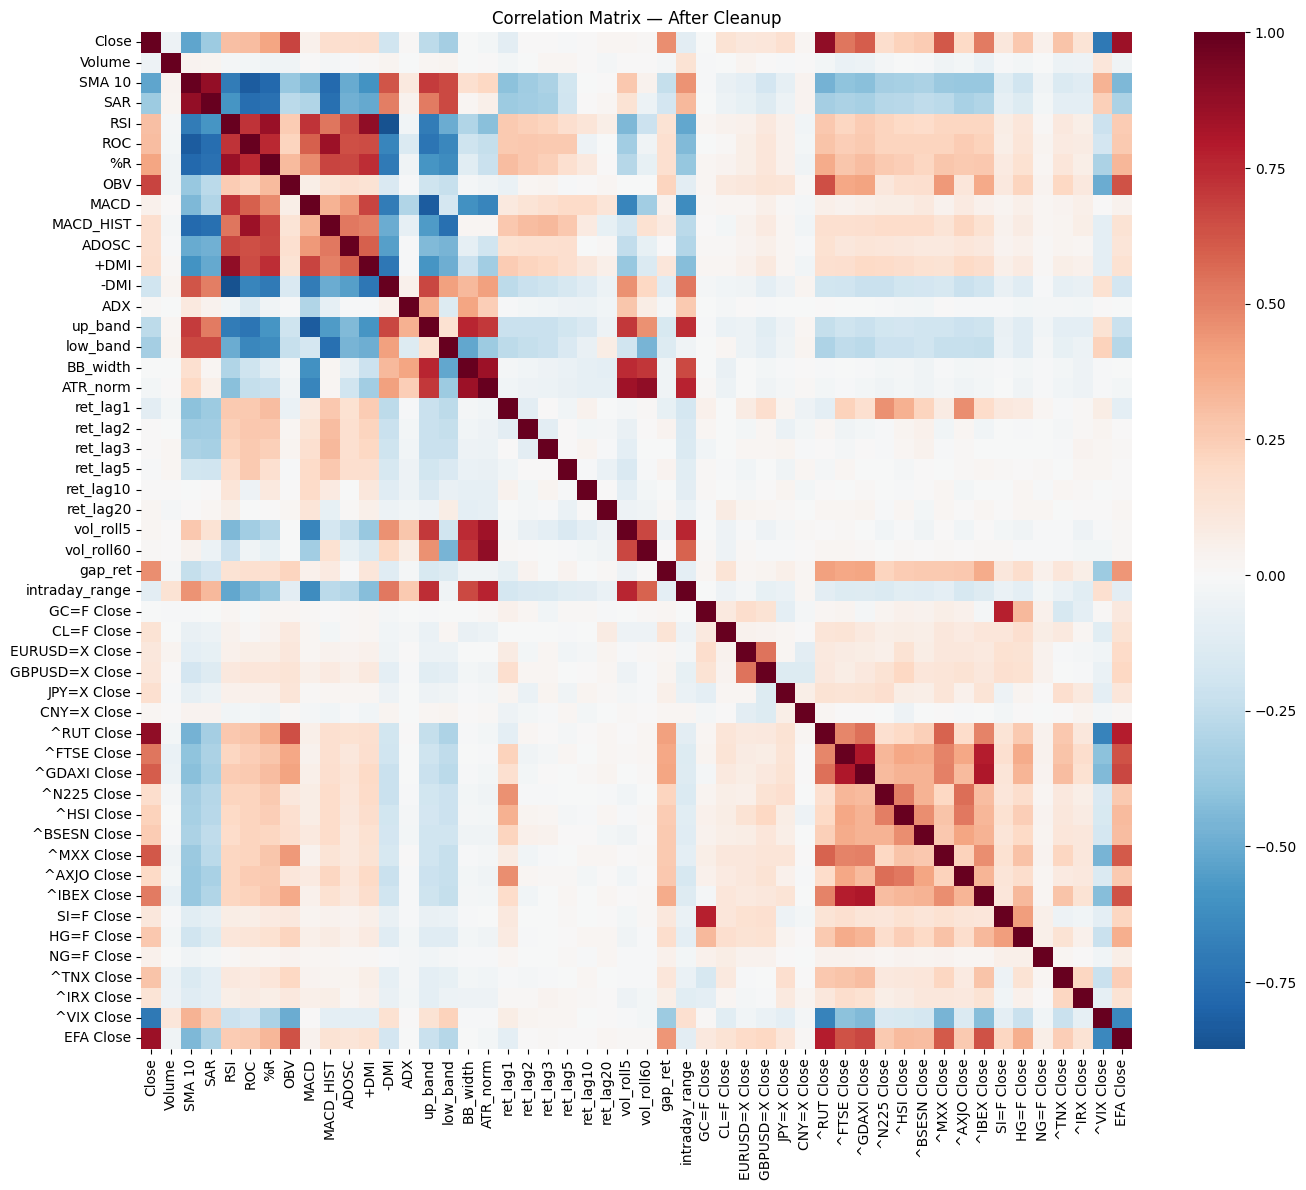

In [7]:
# Correlation heatmap (filtered features)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(X_filtered.drop(columns=to_drop_corr).corr(), cmap="RdBu_r", center=0, ax=ax,
            xticklabels=True, yticklabels=True, fmt=".1f")
ax.set_title("Correlation Matrix — After Cleanup")
plt.tight_layout()
plt.show()

In [8]:
# Final feature set
all_dropped = set(low_imp) | set(to_drop_corr)
keep = [c for c in X.columns if c not in all_dropped]

print(f"Before: {len(X.columns)} features")
print(f"Dropped (low importance): {len(low_imp)}")
print(f"Dropped (high corr):     {len(to_drop_corr)}")
print(f"After:  {len(keep)} features")
print()
print("Keep:")
print(keep)

Before: 67 features
Dropped (low importance): 0
Dropped (high corr):     17
After:  50 features

Keep:
['Close', 'Volume', 'SMA 10', 'SAR', 'RSI', 'ROC', '%R', 'OBV', 'MACD', 'MACD_HIST', 'ADOSC', '+DMI', '-DMI', 'ADX', 'up_band', 'low_band', 'BB_width', 'ATR_norm', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'ret_lag20', 'vol_roll5', 'vol_roll60', 'gap_ret', 'intraday_range', 'GC=F Close', 'CL=F Close', 'EURUSD=X Close', 'GBPUSD=X Close', 'JPY=X Close', 'CNY=X Close', '^RUT Close', '^FTSE Close', '^GDAXI Close', '^N225 Close', '^HSI Close', '^BSESN Close', '^MXX Close', '^AXJO Close', '^IBEX Close', 'SI=F Close', 'HG=F Close', 'NG=F Close', '^TNX Close', '^IRX Close', '^VIX Close', 'EFA Close']
